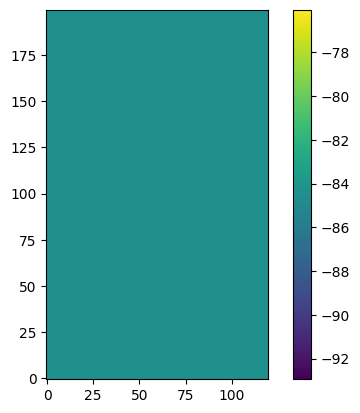

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw

n, m, k = 200, 200, 120
p = 50
D_blood = 0.6
D_i = 0.3
D_e = 0.3
# D_model = (D_i * D_e) / (D_i + D_e)
D_model = D_i + D_e
slab = np.ones((n, m, k))

D_ac = np.ones_like(slab, dtype=np.float64)
D_ac[:, :, :p] = D_blood
D_ac[:, :, p:] = D_model / 9
D_al = np.ones_like(slab, dtype=np.float64)
D_al[:, :, :p] = D_blood
D_al[:, :, p:] = D_model

phi_k = np.linspace(- np.pi / 3, np.pi / 3, k-p)

fibers = np.zeros(slab.shape + (3,), dtype=np.float64)
fibers[:, :, :p, 0] = 1.

for k_i, phi in enumerate(phi_k):
    fibers[:, :, p + k_i, 0] = np.cos(phi)
    fibers[:, :, p + k_i, 1] = np.sin(phi)
    fibers[:, :, p + k_i, 2] = 0

tissue = fw.CardiacTissueGrid(slab.shape, dr=0.1)
tissue.D_ac = D_ac
tissue.D_al = D_al
tissue.fibers = fibers

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(0, 100, 1.,
                                           n//4, 3*m//4,
                                           m//4, 3*m//4,
                                           k//2-1, k//2+1))

simulation = fw.CardiacSimulation(dt=0.01, t_max=0.1, backend="mlx")
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.cardiac_model = fw.LuoRudy91()
simulation.cardiac_model.D_model = 1.

simulation.initialize()

plt.imshow(simulation.cardiac_model.output("u")[n//2], origin="lower")
plt.colorbar()
plt.show()

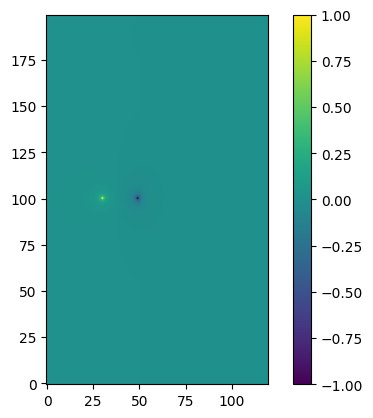

In [3]:
import scipy.sparse as sparse
import pyamg


def internal_indexes(A, dirichlet_idx):
    mask = np.ones(A.shape[0], dtype=bool)
    mask[dirichlet_idx] = False
    internal_idx = np.where(mask)[0]
    return internal_idx


def apply_dirichlet_bc(A, x0, internal_idx, dirichlet_idx, b=None):
    if b is None:
        b = np.zeros(x0.shape[0])

    A_internal = A[internal_idx][:, internal_idx]
    A_boundary = A[internal_idx][:, dirichlet_idx]
    b = b[internal_idx] - A_boundary @ x0[dirichlet_idx]
    return A_internal, b


def poisson_solver(K, mesh, left_id, right_id):
    mask = mesh == 1
    i_tr = np.zeros(mesh.shape, dtype=np.float64)
    i_tr[*left_id] = -1
    i_tr[*right_id] = 1

    electrode_id = np.vstack([left_id, right_id]).T
    dirichlet_idx = np.ravel_multi_index(electrode_id, mesh.shape)
    internal_idx = internal_indexes(K, dirichlet_idx)
    K_internal, b = apply_dirichlet_bc(K, i_tr.flatten(), internal_idx, dirichlet_idx)
    
    ml = pyamg.ruge_stuben_solver(K_internal)
    x = ml.solve(b, tol=1e-8)

    i_tr.flat[internal_idx] = x
    return i_tr, x

K = simulation.diffusion_model.weights[0]

mesh = simulation.cardiac_tissue.mesh

left_id = [n//2, m//2, p-1]
right_id = [n//2, m//2, p-20]

i_tr, x = poisson_solver(K, mesh, left_id, right_id)

plt.imshow(i_tr[n//2], origin="lower")
plt.colorbar()
plt.show()

In [33]:
import finitewave as fw
import numpy as np
import mlx.core as mx
from scipy import sparse


class LeadFieldTracker(fw.core.tracker.Tracker):
    def __init__(self, weights, **kwargs):
        super().__init__(**kwargs)
        self.egms = []
        self.weights = 2 * weights

    def initialize(self, simulation):
        super().initialize(simulation)
        
    def calc_egms(self):
        u_old = self.simulation.solver.u_old
        u = self.simulation.cardiac_model.u
        rhs = self.simulation.solver.rhs
        dt = self.simulation.dt
        dr = self.simulation.cardiac_tissue.dr

        egms = self.simulation.backend.lib.sum((u - u_old - dt * rhs) / dt * self.weights * dr**2)
        mx.eval(egms)
        return egms

    def _track(self):
        egms = self.calc_egms()
        self.egms.append(egms)
    
    @property
    def output(self):
        return np.squeeze(self.egms)
    

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw

D_blood = 0.6
D_i = 0.3
D_e = 0.3
D_model = (D_i * D_e) / (D_i + D_e)
slab = np.ones((n, m, k-p))

D_ac = np.ones_like(slab, dtype=np.float64)
D_ac[:] = D_blood
D_ac[:] = D_model / 9
D_al = np.ones_like(slab, dtype=np.float64)
D_al[:] = D_blood
D_al[:] = D_model

phi_k = np.linspace(- np.pi / 3, np.pi / 3, k-p)

fibers = np.zeros(slab.shape + (3,), dtype=np.float64)

for k_i, phi in enumerate(phi_k):
    fibers[:, :, k_i, 0] = np.cos(phi)
    fibers[:, :, k_i, 1] = np.sin(phi)
    fibers[:, :, k_i, 2] = 0


def run_simulation(density=0., t_max=50, mask=None):
    if mask is None:
        mask = np.ones(slab.shape, dtype=bool)

    tissue = fw.CardiacTissueGrid(slab.shape, dr=0.1)
    tissue.D_ac = D_ac
    tissue.D_al = D_al
    tissue.fibers = fibers
    # tissue.mesh += (np.random.rand(*tissue.mesh.shape) < density).astype(tissue.mesh.dtype)
    tissue.mesh[mask] += (np.random.rand(*tissue.mesh[mask].shape) < density).astype(tissue.mesh.dtype)

    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimCurrentCoord(10, 100, 1.,
                                               n//4, 3*m//4,
                                               m//4, 3*m//4,
                                               0, 1))

    lead_field_tracker = LeadFieldTracker(weights=i_tr[:, :, p:].flatten(), step=10)
    tracker_sequence = fw.TrackerSequence()
    tracker_sequence.add_tracker(lead_field_tracker)


    stim_prepacing = fw.StimSingleCell(0.005)
    stim_prepacing.add_stim(n_beats=100, cycle_length=1000, curr_value=20, duration=2)

    model = fw.LuoRudy91()
    model.prepacing(stim_prepacing)

    simulation = fw.CardiacSimulation(dt=0.005, t_max=t_max, backend="mlx")
    simulation.cardiac_tissue = tissue
    simulation.stim_sequence = stim_sequence
    simulation.cardiac_model = model
    simulation.cardiac_model.D_model = 1.
    simulation.tracker_sequence = tracker_sequence

    simulation.run()

    return lead_field_tracker.output, simulation.cardiac_model.output("u")


# densities = [0., 0.1, 0.2, 0.3, 0.4, 0.5]
# t_max = 100
# egms = [run_simulation(density, t_max) for density in densities[:]]

In [122]:
mask = np.zeros(slab.shape, dtype=bool)
mask[10: -25, 15: -20, 10:50] = True
egm_04, u_04 = run_simulation(0.6, 100, mask=mask)

Running LuoRudy91 on (200, 200, 70) Grid: 100%|██████████| 20000/20000 [01:59<00:00, 167.53it/s]


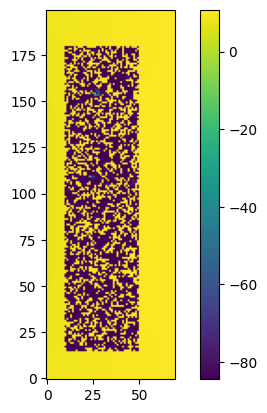

In [123]:
plt.imshow(u_04[n//2], origin="lower")
plt.colorbar()
plt.show()

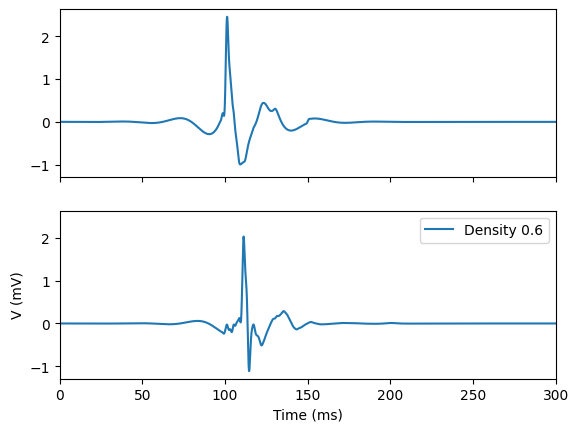

In [125]:
egm_00 = np.zeros(int(300 / 0.05))
i_start = int(100 / 0.05)
egm_00[i_start: i_start+len(egms[0])] = egms[0]
t_00 = np.arange(len(egm_00)) * 0.05

egm_x = np.zeros(int(300 / 0.05))
i_start = int(100 / 0.05)
egm_x[i_start: i_start+len(egm_04)] = egm_04
egm_x[i_start+len(egm_04):] = egm_04[-1]
t_x = np.arange(len(egm_x)) * 0.05

fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)
axs[0].plot(t_00, apply_bi_egm_filter(egm_00, fs=20000), label="Density 0.0")
axs[1].plot(t_x, apply_bi_egm_filter(egm_x, fs=20000), label="Density 0.6")
axs[1].set_xlim(0, 300)
axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("V (mV)")
axs[1].legend()
plt.show()

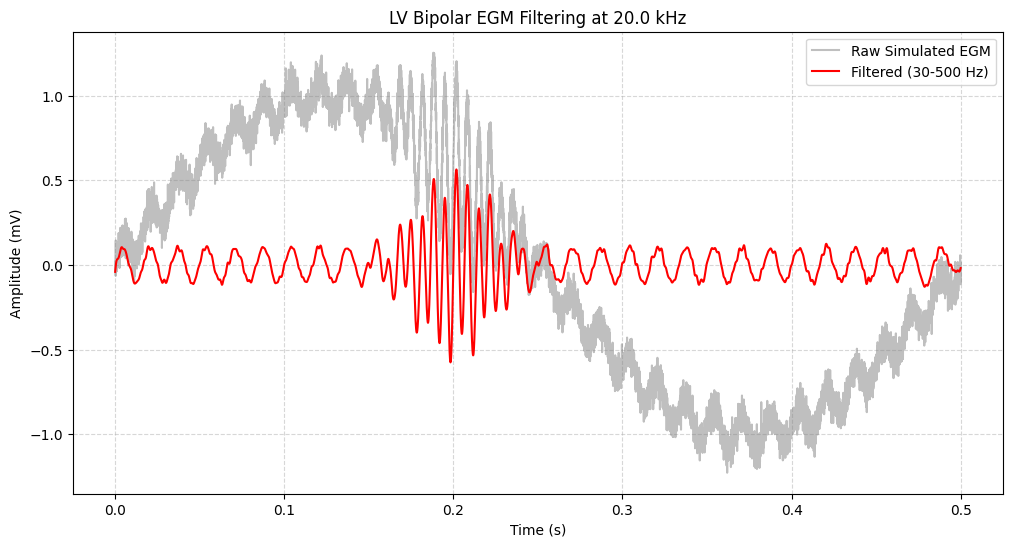

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

def apply_bi_egm_filter(data, fs=20000):
    """
    Applies a clinical-grade bandpass filter (30-500 Hz) to an LV biEGM.
    Uses SOS (Second-Order Sections) for stability at high sampling rates.
    """
    # 1. Define Filter Parameters
    low_cut = 30.0   # Hz
    high_cut = 500.0 # Hz
    order = 4        # 4th order filter
    
    # 2. Design the Filter in SOS format
    # Using 'sos' output is critical for stability at 20kHz
    sos = butter(order, [low_cut, high_cut], btype='bandpass', fs=fs, output='sos')
    
    # 3. Apply Filter (Zero-phase)
    # sosfiltfilt applies the filter forward and backward to prevent phase shift
    filtered_signal = sosfiltfilt(sos, data)
    
    return filtered_signal

# --- Example Usage ---
fs = 20000
duration = 0.5  # seconds
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# Simulated biEGM: Low freq (drift) + 150Hz signal + 60Hz hum + noise
raw_signal = (np.sin(2 * np.pi * 2 * t) +              # Baseline drift (2Hz)
              0.5 * np.exp(-1000 * (t - 0.2)**2) * # Sharp EGM deflection
              np.sin(2 * np.pi * 150 * t) +             # EGM frequency content
              0.1 * np.sin(2 * np.pi * 60 * t) +        # Power line noise (60Hz)
              0.05 * np.random.normal(size=t.shape))    # Electronic noise

# Apply the filter
cleaned_egm = apply_bi_egm_filter(raw_signal, fs)

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(t, raw_signal, label='Raw Simulated EGM', alpha=0.5, color='gray')
plt.plot(t, cleaned_egm, label='Filtered (30-500 Hz)', color='red', linewidth=1.5)
plt.title(f"LV Bipolar EGM Filtering at {fs/1000} kHz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

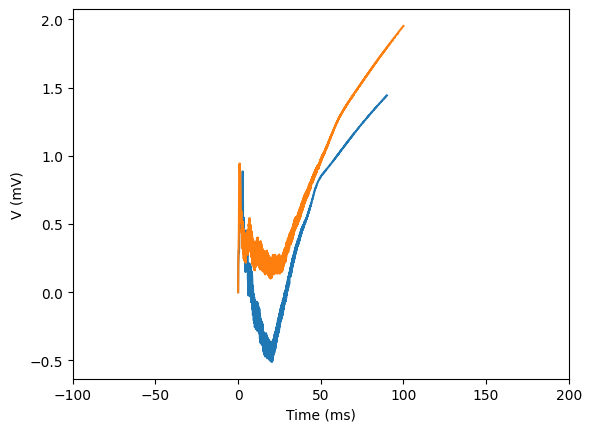

In [54]:
for density, egm in zip(densities, egms[-2:]):
    times = np.arange(len(egm)) * 10 * simulation.dt
    plt.plot(times, egm, label=f"Density: {density:.1f}")
plt.xlim(-100, 200)
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")
plt.show()

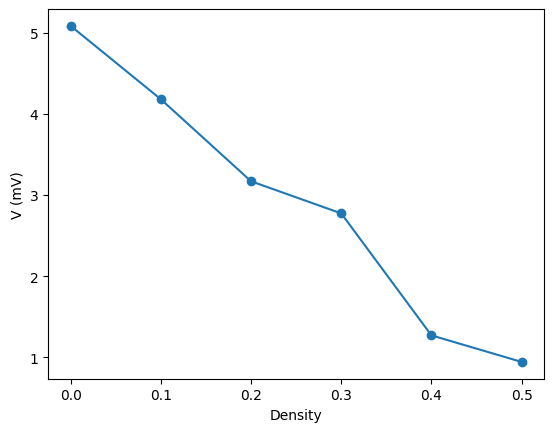

In [52]:
amplitude = [np.max(egm[:300]) - np.min(egm[:300]) for egm in egms]
plt.plot(densities, np.array(amplitude), marker='o')
plt.xlabel("Density")
plt.ylabel("V (mV)")
plt.show()